# Benchmarking classification models on MNIST-1D

In [1]:
import sys
sys.path.append('./mnist1d/notebooks/')
sys.path.append('./mnist1d/mnist1d/')

from models import ConvBase, MLPBase, LinearBase, GRUBase
from train import get_model_args, train_model
from mnist1d.utils import set_seed

import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

import pickle


In [3]:
with open("/home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data.pkl", "rb") as f:
    data = pickle.load(f)

## Run the benchmarks

In [4]:
# Note: if you run on a GPU, the walltimes will be _much_ lower

args = get_model_args()
args.total_steps = 6000
args.device = DEVICE

set_seed(args.seed)
model = ConvBase(output_size=args.output_size)
results_cnn = train_model(data, model, args)
print()

set_seed(args.seed)
model = GRUBase(input_size=1, output_size=args.output_size)
results_gru = train_model(data, model, args)
print()

set_seed(args.seed)
model = MLPBase(args.input_size, args.output_size)
results_mlp = train_model(data, model, args)
print()

set_seed(args.seed)
model = LinearBase(args.input_size, args.output_size)
results_lin = train_model(data, model, args)

Initialized ConvBase model with 5210 parameters
step 1000, dt 1.43s, train_loss 7.425e-02, test_loss 4.339e-01, train_acc 95.7, test_acc 87.8
step 2000, dt 1.40s, train_loss 5.478e-02, test_loss 5.110e-01, train_acc 98.4, test_acc 89.6
step 3000, dt 1.51s, train_loss 1.690e-02, test_loss 6.684e-01, train_acc 99.1, test_acc 89.0
step 4000, dt 1.53s, train_loss 3.128e-03, test_loss 8.557e-01, train_acc 98.3, test_acc 89.2
step 5000, dt 1.43s, train_loss 1.594e-02, test_loss 6.940e-01, train_acc 99.9, test_acc 92.3
step 6000, dt 1.40s, train_loss 1.352e-05, test_loss 6.929e-01, train_acc 100.0, test_acc 92.7

Initialized GRUBase model with 5134 parameters
step 1000, dt 11.63s, train_loss 1.958e-01, test_loss 4.194e-01, train_acc 92.5, test_acc 86.5
step 2000, dt 11.47s, train_loss 9.307e-02, test_loss 3.994e-01, train_acc 96.6, test_acc 88.0
step 3000, dt 11.82s, train_loss 8.957e-02, test_loss 5.005e-01, train_acc 96.0, test_acc 87.9
step 4000, dt 11.57s, train_loss 1.678e-02, test_loss 

In [5]:
# Shuffle the pixels

import numpy as np

np.random.seed(42)
shuffled_order = np.random.permutation(data['x'].shape[1])

data_shuff = data.copy()
data_shuff['x'] = data_shuff['x'][:, shuffled_order]
data_shuff['x_test'] = data_shuff['x_test'][:, shuffled_order]

In [6]:
set_seed(args.seed)
model = ConvBase(output_size=args.output_size)
results_cnn_shuff = train_model(data_shuff, model, args)
print()

set_seed(args.seed)
model = GRUBase(input_size=1, output_size=args.output_size)
results_gru_shuff = train_model(data_shuff, model, args)
print()

set_seed(args.seed)
model = MLPBase(args.input_size, args.output_size)
results_mlp_shuff = train_model(data_shuff, model, args)
print()

set_seed(args.seed)
model = LinearBase(args.input_size, args.output_size)
results_lin_shuff = train_model(data_shuff, model, args)

Initialized ConvBase model with 5210 parameters
step 1000, dt 1.66s, train_loss 5.792e-01, test_loss 1.462e+00, train_acc 74.2, test_acc 55.6
step 2000, dt 1.52s, train_loss 3.467e-01, test_loss 2.012e+00, train_acc 84.0, test_acc 57.2
step 3000, dt 1.70s, train_loss 1.968e-01, test_loss 2.462e+00, train_acc 90.7, test_acc 56.5
step 4000, dt 1.68s, train_loss 2.023e-01, test_loss 3.500e+00, train_acc 90.3, test_acc 56.8
step 5000, dt 1.49s, train_loss 2.650e-01, test_loss 4.343e+00, train_acc 91.5, test_acc 56.3
step 6000, dt 1.82s, train_loss 2.165e-01, test_loss 5.233e+00, train_acc 91.4, test_acc 56.1

Initialized GRUBase model with 5134 parameters
step 1000, dt 13.42s, train_loss 7.414e-01, test_loss 1.173e+00, train_acc 72.8, test_acc 53.2
step 2000, dt 11.30s, train_loss 6.120e-01, test_loss 1.497e+00, train_acc 79.3, test_acc 52.4
step 3000, dt 10.67s, train_loss 4.797e-01, test_loss 1.789e+00, train_acc 83.2, test_acc 50.9
step 4000, dt 10.54s, train_loss 3.836e-01, test_loss 2

## Construct the figure

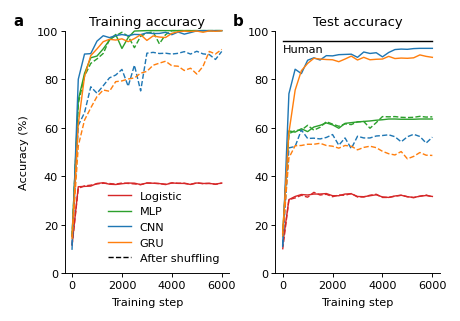

In [7]:
import pylab as plt

# Figure style (loading from the web to make running in a Colab easier)
plt.style.use('https://github.com/greydanus/mnist1d/raw/master/notebooks/mpl_style.txt')

fig, axs = plt.subplots(ncols=2, figsize=(3.25, 2.25))

steps = 6000
eval_every = 250
t = range(0, steps + 1, eval_every)

axs[0].plot(t, results_lin['train_acc'], '-', color='tab:red', label='Logistic')
axs[0].plot(t, results_lin_shuff['train_acc'], '--', color='tab:red')

axs[0].plot(t, results_mlp['train_acc'], '-', color='tab:green', label='MLP', clip_on=False)
axs[0].plot(t, results_mlp_shuff['train_acc'], '--', color='tab:green', clip_on=False)

axs[0].plot(t, results_cnn['train_acc'], '-', color='tab:blue', label='CNN', clip_on=False)
axs[0].plot(t, results_cnn_shuff['train_acc'], '--', color='tab:blue', clip_on=False)

axs[0].plot(t, results_gru['train_acc'], '-', color='tab:orange', label='GRU', clip_on=False)
axs[0].plot(t, results_gru_shuff['train_acc'], '--', color='tab:orange', clip_on=False)

axs[0].plot(t, [-1] * len(t), 'k--', label='After shuffling')

###

axs[1].plot(t, results_lin['test_acc'], '-', color='tab:red', label='logistic')
axs[1].plot(t, results_lin_shuff['test_acc'], '--', color='tab:red')

axs[1].plot(t, results_mlp['test_acc'], '-', color='tab:green', label='mlp')
axs[1].plot(t, results_mlp_shuff['test_acc'], '--', color='tab:green')

axs[1].plot(t, results_cnn['test_acc'], '-', color='tab:blue', label='cnn')
axs[1].plot(t, results_cnn_shuff['test_acc'], '--', color='tab:blue')

axs[1].plot(t, results_gru['test_acc'], '-', color='tab:orange', label='gru')
axs[1].plot(t, results_gru_shuff['test_acc'], '--', color='tab:orange')

axs[1].plot(t, [95.8] * len(t), 'k-')
axs[1].text(0, 91, 'Human')

axs[0].set_title('Training accuracy')
axs[1].set_title('Test accuracy')
axs[1].set_xlabel("Training step")
axs[0].set_xlabel("Training step")
axs[0].set_ylabel("Accuracy (%)")
axs[0].legend()
axs[0].set_ylim(0, 100)
axs[1].set_ylim(0, 100)

fig.text(0, .95, 'a', fontsize=8, weight='bold')
fig.text(.5, .95, 'b', fontsize=8, weight='bold')

plt.show()

fig.savefig('figures/benchmark.png', dpi=300)
fig.savefig('figures/benchmark.pdf')

In [8]:
# Model Accuracy (%) table

from IPython.display import display, HTML
from html import escape

def final_test_acc(results_name):
    """Get the final test accuracy from a results_* object."""
    results = globals().get(results_name)

    if not isinstance(results, dict):
        return "—"

    test_acc = results.get("test_acc")

    if test_acc is None or len(test_acc) == 0:
        return "—"

    return f"{float(test_acc[-1]):.0f}"

headers = [
    "Dataset",
    "Logistic regression",
    "MLP",
    "CNN",
    "GRU",
    "Human expert",
]

rows = [
    [
        "MNIST",
        "94 ± 0.5",
        "> 99",
        "> 99",
        "> 99",
        "> 99",
    ],
    [
        "MNIST-1D",
        final_test_acc("results_lin"),
        final_test_acc("results_mlp"),
        final_test_acc("results_cnn"),
        final_test_acc("results_gru"),
        "96 ± 1",
    ],
    [
        "MNIST-1D (shuffled)",
        final_test_acc("results_lin_shuff"),
        final_test_acc("results_mlp_shuff"),
        final_test_acc("results_cnn_shuff"),
        final_test_acc("results_gru_shuff"),
        "~30 ± 10",
    ],
]

header_html = "".join(f"<th>{escape(h)}</th>" for h in headers)

rows_html = ""
for row in rows:
    rows_html += "<tr>" + "".join(f"<td>{escape(str(value))}</td>" for value in row) + "</tr>"

html = f"""
<h3>Model Accuracy (%)</h3>
<table style="border-collapse: collapse; text-align: center;">
    <thead>
        <tr>{header_html}</tr>
    </thead>
    <tbody>
        {rows_html}
    </tbody>
</table>
<style>
    table th, table td {{
        border: 1px solid #999;
        padding: 6px 12px;
    }}
    table th:first-child,
    table td:first-child {{
        text-align: left;
    }}
</style>
"""

display(HTML(html))

Dataset,Logistic regression,MLP,CNN,GRU,Human expert
MNIST,94 ± 0.5,> 99,> 99,> 99,> 99
MNIST-1D,32,64,93,89,96 ± 1
MNIST-1D (shuffled),32,64,56,49,~30 ± 10


In [ ]:
def run_marker_accuracy_experiments(
    default_url="/home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data.pkl",
    marker_url="/home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data_including_marker.pkl",
    reversed_marker_url="/home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data_including_marker_reversed.pkl",
    total_steps=6000,
    use_marker_as_input=True,
    run_shuffled=True,
):
    import sys
    import os
    import pickle
    import copy
    import numpy as np

    sys.path.append("./mnist1d/notebooks/")
    sys.path.append("./mnist1d/mnist1d/")

    import torch
    import torch.nn as nn

    from models import ConvBase, MLPBase, LinearBase, GRUBase
    from train import get_model_args, train_model
    from mnist1d.utils import set_seed

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # ------------------------------------------------------
    # Marker-aware models
    # ------------------------------------------------------

    class ConvMarkerBase(nn.Module):
        """
        Input is flattened as [signal, marker_mask].
        Internally reshaped to 2 channels: shape (batch, 2, seq_len).
        """

        def __init__(self, seq_len, output_size=10):
            super().__init__()
            self.seq_len = seq_len

            self.features = nn.Sequential(
                nn.Conv1d(2, 25, kernel_size=5, stride=2, padding=2),
                nn.ReLU(),
                nn.Conv1d(25, 25, kernel_size=5, stride=2, padding=2),
                nn.ReLU(),
                nn.Conv1d(25, 25, kernel_size=5, stride=2, padding=2),
                nn.ReLU(),
            )

            with torch.no_grad():
                dummy = torch.zeros(1, 2, seq_len)
                flat_dim = self.features(dummy).reshape(1, -1).shape[1]

            self.classifier = nn.Linear(flat_dim, output_size)

        def forward(self, x):
            batch_size = x.shape[0]
            x = x.reshape(batch_size, 2, self.seq_len)
            x = self.features(x)
            x = x.reshape(batch_size, -1)
            return self.classifier(x)

    class GRUMarkerBase(nn.Module):
        """
        Input is flattened as [signal, marker_mask].
        Internally reshaped to sequence input: shape (batch, seq_len, 2).
        """

        def __init__(self, seq_len, output_size=10, hidden_size=64):
            super().__init__()
            self.seq_len = seq_len

            self.gru = nn.GRU(
                input_size=2,
                hidden_size=hidden_size,
                batch_first=True,
            )

            self.classifier = nn.Linear(hidden_size, output_size)

        def forward(self, x):
            batch_size = x.shape[0]
            x = x.reshape(batch_size, 2, self.seq_len)
            x = x.transpose(1, 2)
            out, hidden = self.gru(x)
            return self.classifier(out[:, -1, :])

    # ------------------------------------------------------
    # Helpers
    # ------------------------------------------------------

    def load_pkl(path):
        if not os.path.exists(path):
            raise FileNotFoundError(f"Could not find: {path}")

        with open(path, "rb") as f:
            return pickle.load(f)

    def has_marker(data):
        return "marker_mask" in data and "marker_mask_test" in data

    def add_zero_marker_fields(data):
        data = copy.deepcopy(data)
        data["marker_mask"] = np.zeros_like(data["x"])
        data["marker_mask_test"] = np.zeros_like(data["x_test"])
        return data

    def make_model_input_data(train_data, test_data, use_marker):
        train_data = copy.deepcopy(train_data)
        test_data = copy.deepcopy(test_data)

        seq_len = train_data["x"].shape[1]

        if use_marker:
            if not has_marker(train_data):
                raise ValueError("Training data has no marker_mask / marker_mask_test.")

            if not has_marker(test_data):
                test_data = add_zero_marker_fields(test_data)

            x_train = np.concatenate(
                [train_data["x"], train_data["marker_mask"]],
                axis=1,
            )

            x_test = np.concatenate(
                [test_data["x_test"], test_data["marker_mask_test"]],
                axis=1,
            )

        else:
            x_train = train_data["x"]
            x_test = test_data["x_test"]

        data = {
            "x": x_train,
            "y": train_data["y"],
            "x_test": x_test,
            "y_test": test_data["y_test"],
        }

        if "t" in train_data:
            data["t"] = train_data["t"]

        return data, seq_len

    def make_shuffled_data(data, seq_len, use_marker):
        data_shuff = copy.deepcopy(data)

        np.random.seed(42)

        if use_marker:
            order = np.random.permutation(seq_len)

            x_signal = data["x"][:, :seq_len]
            x_marker = data["x"][:, seq_len:]

            x_test_signal = data["x_test"][:, :seq_len]
            x_test_marker = data["x_test"][:, seq_len:]

            data_shuff["x"] = np.concatenate(
                [x_signal[:, order], x_marker[:, order]],
                axis=1,
            )

            data_shuff["x_test"] = np.concatenate(
                [x_test_signal[:, order], x_test_marker[:, order]],
                axis=1,
            )

        else:
            order = np.random.permutation(data["x"].shape[1])
            data_shuff["x"] = data["x"][:, order]
            data_shuff["x_test"] = data["x_test"][:, order]

        return data_shuff

    def final_acc(results):
        test_acc = results.get("test_acc")
        if test_acc is None or len(test_acc) == 0:
            return None
        return float(test_acc[-1])

    def format_acc(value):
        if value is None:
            return "—"
        return f"{value:.1f}"

    # ------------------------------------------------------
    # Training
    # ------------------------------------------------------

    def train_all_models(data, experiment_name, seq_len, use_marker_model):
        print()
        print("=" * 80)
        print(experiment_name)
        print("=" * 80)
        print("x:", data["x"].shape)
        print("y:", data["y"].shape)
        print("x_test:", data["x_test"].shape)
        print("y_test:", data["y_test"].shape)

        args = get_model_args()
        args.total_steps = total_steps
        args.device = DEVICE
        args.input_size = data["x"].shape[1]

        results = {}

        set_seed(args.seed)
        if use_marker_model:
            model = ConvMarkerBase(seq_len=seq_len, output_size=args.output_size)
        else:
            model = ConvBase(output_size=args.output_size)
        results["CNN"] = train_model(data, model, args)
        print()

        set_seed(args.seed)
        if use_marker_model:
            model = GRUMarkerBase(seq_len=seq_len, output_size=args.output_size)
        else:
            model = GRUBase(input_size=1, output_size=args.output_size)
        results["GRU"] = train_model(data, model, args)
        print()

        set_seed(args.seed)
        model = MLPBase(args.input_size, args.output_size)
        results["MLP"] = train_model(data, model, args)
        print()

        set_seed(args.seed)
        model = LinearBase(args.input_size, args.output_size)
        results["Logistic"] = train_model(data, model, args)
        print()

        return results

    def train_case(case_name, train_data, test_data, use_marker):
        data, seq_len = make_model_input_data(
            train_data=train_data,
            test_data=test_data,
            use_marker=use_marker,
        )

        results = train_all_models(
            data=data,
            experiment_name=case_name,
            seq_len=seq_len,
            use_marker_model=use_marker,
        )

        if run_shuffled:
            data_shuff = make_shuffled_data(
                data=data,
                seq_len=seq_len,
                use_marker=use_marker,
            )

            results_shuff = train_all_models(
                data=data_shuff,
                experiment_name=case_name + " shuffled",
                seq_len=seq_len,
                use_marker_model=use_marker,
            )
        else:
            results_shuff = None

        return {
            "normal": results,
            "shuffled": results_shuff,
        }

    # ------------------------------------------------------
    # Load data
    # ------------------------------------------------------

    default_data = load_pkl(default_url)
    marker_data = load_pkl(marker_url)
    reversed_marker_data = load_pkl(reversed_marker_url)

    print("Loaded datasets:")
    print("Default:", default_url)
    print("Marker:", marker_url)
    print("Reversed marker:", reversed_marker_url)

    if use_marker_as_input:
        print()
        print("Marker is used as model input.")
        print("Input format: concat([x, marker_mask])")
        print("CNN/GRU use custom marker-aware models.")
    else:
        print()
        print("Marker exists in the pkl but is ignored.")
        print("Models see only x.")

    # ------------------------------------------------------
    # Experiments
    # ------------------------------------------------------

    vanilla_results = train_case(
        case_name="Vanilla train → vanilla test",
        train_data=default_data,
        test_data=default_data,
        use_marker=False,
    )

    marker_default_results = train_case(
        case_name="Marked train → default test",
        train_data=marker_data,
        test_data=default_data,
        use_marker=use_marker_as_input,
    )

    marker_marker_results = train_case(
        case_name="Marked train → marked test",
        train_data=marker_data,
        test_data=marker_data,
        use_marker=use_marker_as_input,
    )

    marker_reversed_results = train_case(
        case_name="Marked train → reversed-marker test",
        train_data=marker_data,
        test_data=reversed_marker_data,
        use_marker=use_marker_as_input,
    )

    # ------------------------------------------------------
    # Single combined table
    # ------------------------------------------------------

    def row_from_results(name, bundle):
        normal = bundle["normal"]
        shuffled = bundle["shuffled"]

        row = {
            "Case": name,
            "Logistic": format_acc(final_acc(normal["Logistic"])),
            "MLP": format_acc(final_acc(normal["MLP"])),
            "CNN": format_acc(final_acc(normal["CNN"])),
            "GRU": format_acc(final_acc(normal["GRU"])),
        }

        if run_shuffled:
            row.update(
                {
                    "Logistic shuffled": format_acc(final_acc(shuffled["Logistic"])),
                    "MLP shuffled": format_acc(final_acc(shuffled["MLP"])),
                    "CNN shuffled": format_acc(final_acc(shuffled["CNN"])),
                    "GRU shuffled": format_acc(final_acc(shuffled["GRU"])),
                }
            )

        return row

    all_rows = [
        row_from_results("Vanilla train → default test", vanilla_results),
        row_from_results("Marked train → default test", marker_default_results),
        row_from_results("Marked train → marked test", marker_marker_results),
        row_from_results("Marked train → reversed-marked test", marker_reversed_results),
    ]

    columns = ["Case", "Logistic", "MLP", "CNN", "GRU"]

    if run_shuffled:
        columns += [
            "Logistic shuffled",
            "MLP shuffled",
            "CNN shuffled",
            "GRU shuffled",
        ]

    # ------------------------------------------------------
    # Display one table only
    # ------------------------------------------------------

    try:
        from IPython.display import display, HTML
        from html import escape

        def html_table(title, rows, columns):
            header_html = "".join(f"<th>{escape(col)}</th>" for col in columns)

            rows_html = ""
            for row in rows:
                rows_html += "<tr>"
                for col in columns:
                    rows_html += f"<td>{escape(str(row[col]))}</td>"
                rows_html += "</tr>"

            return f"""
            <h3>{escape(title)}</h3>

            <table style="border-collapse: collapse; text-align: center; font-size: 13px;">
                <thead>
                    <tr>{header_html}</tr>
                </thead>
                <tbody>
                    {rows_html}
                </tbody>
            </table>

            <style>
                table th, table td {{
                    border: 1px solid #999;
                    padding: 6px 10px;
                }}
                table th:first-child,
                table td:first-child {{
                    text-align: left;
                    white-space: nowrap;
                }}
            </style>
            """

        display(
            HTML(
                html_table(
                    "Final test accuracy (%)",
                    all_rows,
                    columns,
                )
            )
        )

    except Exception:
        print()
        print("Final test accuracy (%)")
        for row in all_rows:
            print(row)

    return {
        "vanilla": vanilla_results,
        "marked_train_default_test": marker_default_results,
        "marked_train_marked_test": marker_marker_results,
        "marked_train_reversed_test": marker_reversed_results,
        "rows": all_rows,
    }

In [12]:
run_marker_accuracy_experiments(
    default_url="/home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data.pkl",
    marker_url="/home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data_including_marker.pkl",
    reversed_marker_url="/home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data_including_marker_reversed.pkl",
    total_steps=6000,
    use_marker_as_input=True,
)

Loaded datasets:
Default: /home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data.pkl
Marker: /home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data_including_marker.pkl
Reversed marker: /home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data_including_marker_reversed.pkl

Marker is used as model input.
Input format: concat([x, marker_mask])
CNN/GRU use custom marker-aware models.

Vanilla train → vanilla test
x: (4000, 40)
y: (4000,)
x_test: (1000, 40)
y_test: (1000,)
Initialized ConvBase model with 5210 parameters
step 1000, dt 1.51s, train_loss 4.871e-02, test_loss 3.969e-01, train_acc 96.2, test_acc 89.5
step 2000, dt 1.39s, train_loss 5.189e-02, test_loss 3.963e-01, train_acc 98.6, test_acc 91.1
step 3000, dt 1.33s, train_loss 1.110e-02, test_loss 4.782e-01, train_acc 98.0, test_acc 91.1
step 4000, dt 1.40s, train_loss 1.171e-02, test_loss 4.704e-01, train_acc 99.5, test_acc 92.9
step 5000, dt 1.47s, train_loss 3.700e-02, test_loss 5.461e-01, train_acc 99.0, test_acc 93.0
step 6000,

Case,Logistic,MLP,CNN,GRU,Logistic shuffled,MLP shuffled,CNN shuffled,GRU shuffled
Vanilla train → default test,31.3,62.9,94.4,91.0,31.5,65.1,55.6,53.5
Marked train → default test,29.2,51.6,61.0,71.7,29.7,51.8,45.1,51.3
Marked train → marked test,48.1,77.7,97.4,98.7,48.0,78.6,79.8,64.2
Marked train → reversed-marked test,0.0,6.5,7.7,11.3,0.0,6.5,7.4,37.6


{'vanilla': {'normal': {'CNN': {'checkpoints': [ConvBase(
       (conv1): Conv1d(1, 25, kernel_size=(5,), stride=(2,), padding=(1,))
       (conv2): Conv1d(25, 25, kernel_size=(3,), stride=(2,), padding=(1,))
       (conv3): Conv1d(25, 25, kernel_size=(3,), stride=(2,), padding=(1,))
       (linear): Linear(in_features=125, out_features=10, bias=True)
     ),
     ConvBase(
       (conv1): Conv1d(1, 25, kernel_size=(5,), stride=(2,), padding=(1,))
       (conv2): Conv1d(25, 25, kernel_size=(3,), stride=(2,), padding=(1,))
       (conv3): Conv1d(25, 25, kernel_size=(3,), stride=(2,), padding=(1,))
       (linear): Linear(in_features=125, out_features=10, bias=True)
     ),
     ConvBase(
       (conv1): Conv1d(1, 25, kernel_size=(5,), stride=(2,), padding=(1,))
       (conv2): Conv1d(25, 25, kernel_size=(3,), stride=(2,), padding=(1,))
       (conv3): Conv1d(25, 25, kernel_size=(3,), stride=(2,), padding=(1,))
       (linear): Linear(in_features=125, out_features=10, bias=True)
     ),
